# Order Error Rate

> Measure and visualize the rate of order errors by study position.

An order error occurs when a participant recalls a list item at the wrong output position. The item was on the study list but is produced in a serial position that does not match where it was originally studied. The order error rate curve plots these transposition errors at each study position.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `size` | Maximum study positions per item |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.order_error_rate import (
    trial_order_error_rate,
    order_error_rate,
    plot_order_error_rate,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "Order Error Rate"
data_path = "data/Gordon2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
size = 3
trial_query = "jnp.logical_and(data['condition'] == 2, data['listLength'] == 7)"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

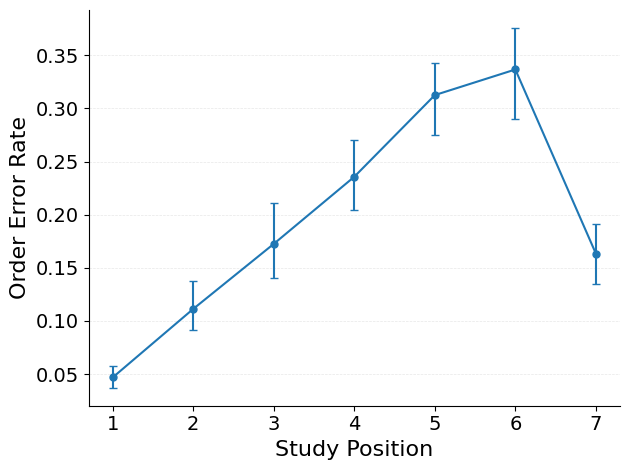

In [5]:
#| code-summary: Plot order error rate
#| label: fig-order-error-rate
#| fig-cap: "Order error rate by study position."
plot_order_error_rate(datasets=data, trial_masks=trial_mask, size=size)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_order_error_rate)

---

### plot_order_error_rate

>      plot_order_error_rate (datasets:Union[Sequence[jaxcmr.typing.RecallDatase
>                             t],jaxcmr.typing.RecallDataset], trial_masks:Union
>                             [Sequence[jaxtyping.Bool[Array,'trial_count']],jax
>                             typing.Bool[Array,'trial_count']],
>                             color_cycle:Optional[list[str]]=None,
>                             labels:Optional[Sequence[str]]=None,
>                             contrast_name:Optional[str]=None,
>                             axis:Optional[matplotlib.axes._axes.Axes]=None,
>                             size:int=3, confidence_level:float=0.95)

*Plot order error rate curves with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with order error rate curves.** |

In [7]:
#| echo: false
show_doc(order_error_rate)

---

### order_error_rate

>      order_error_rate (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Return position-specific order error rate.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Mean order error rate at each study position.** |

In [8]:
# Items 1-3 studied; item 2 recalled at position 1 (order error)
recalls = jnp.array([2, 1, 3], dtype=jnp.int32)
presentations = jnp.array([1, 2, 3], dtype=jnp.int32)

result = trial_order_error_rate(recalls, presentations, size=1)
# Position 1 got item 2 (order error), position 2 got item 1 (order error)
assert jnp.array_equal(result, jnp.array([True, True, False]))

In [9]:
#| echo: false
show_doc(trial_order_error_rate)

---

### trial_order_error_rate

>      trial_order_error_rate
>                              (recalls:jaxtyping.Integer[Array,'recall_position
>                              s'], presentations:jaxtyping.Integer[Array,'study
>                              _positions'], size:int=3)

*Flag order errors at each study position for one trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| recalls | Integer[Array, 'recall_positions'] |  | Recall sequence for a trial. 1-indexed; 0 pads. |
| presentations | Integer[Array, 'study_positions'] |  | Presented item IDs for the trial. 1-indexed; 0 pads. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Bool[Array, 'study_positions']** |  | **True where a list item was recalled in the wrong position.** |

In [10]:
# All items in correct order -> no order errors
result = trial_order_error_rate(
    jnp.array([1, 2, 3], dtype=jnp.int32),
    jnp.array([1, 2, 3], dtype=jnp.int32),
    size=1,
)
assert jnp.array_equal(result, jnp.array([False, False, False]))